In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
games = pd.read_csv("/content/games.csv")
vgsales = pd.read_csv("/content/vgsales.csv")

Basic inspection

In [ ]:
games.head()

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


In [ ]:
games.shape

(1512, 14)

In [ ]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


Missing Values Analysis

In [ ]:
games.isna().sum()

,0
Unnamed: 0,0
Title,0
Release Date,0
Team,1
Rating,13
Times Listed,0
Number of Reviews,0
Genres,0
Summary,1
Reviews,0


In [ ]:
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
vgsales.shape

(16598, 11)

In [ ]:
vgsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
vgsales.isna().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


Data Cleaning & Preprocessing

1.1

Drop unnecessary column

In [ ]:
games = games.drop(columns=['Unnamed: 0'])

Handle missing values

In [ ]:
games.isna().sum()

,0
Title,0
Release Date,0
Team,1
Rating,13
Times Listed,0
Number of Reviews,0
Genres,0
Summary,1
Reviews,0
Plays,0


In [ ]:
games['Team'] = games['Team'].fillna('Unknown')
games['Summary'] = games['Summary'].fillna('Not Available')
games['Rating'] = games['Rating'].fillna(games['Rating'].median())

Convert engagement columns to numeric

Right now columns like Plays, Wishlist look numeric but are strings ('17K', '3.9K').

In [ ]:
engagement_cols = [
    'Times Listed', 'Number of Reviews',
    'Plays', 'Playing', 'Backlogs', 'Wishlist'
]

In [ ]:
def convert_k(value):
    if isinstance(value, str):
        value = value.replace('K', '').replace('M', '')
        return float(value)
    return value

In [ ]:
for col in engagement_cols:
    games[col] = games[col].apply(convert_k)


Convert Release Date to datetime


In [ ]:
games['Release Date'] = pd.to_datetime(games['Release Date'], errors='coerce')

In [ ]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              1512 non-null   object        
 1   Release Date       1509 non-null   datetime64[ns]
 2   Team               1512 non-null   object        
 3   Rating             1512 non-null   float64       
 4   Times Listed       1512 non-null   float64       
 5   Number of Reviews  1512 non-null   float64       
 6   Genres             1512 non-null   object        
 7   Summary            1512 non-null   object        
 8   Reviews            1512 non-null   object        
 9   Plays              1512 non-null   float64       
 10  Playing            1512 non-null   float64       
 11  Backlogs           1512 non-null   float64       
 12  Wishlist           1512 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(5)
memory usage: 153.7

In [ ]:
games.isna().sum()

,0
Title,0
Release Date,3
Team,0
Rating,0
Times Listed,0
Number of Reviews,0
Genres,0
Summary,0
Reviews,0
Plays,0


Only 3 rows out of 1512
Dropping them may remove otherwise useful engagement data
They won’t affect time-series analysis meaningfully

I retained rows with missing release dates since they represent less than 0.2% of the dataset and do not materially impact trend analysis

Remove unnecessary column (Rank is not useful analytically (it’s just ordering)).





In [ ]:
vgsales = vgsales.drop(columns=['Rank'])

In [ ]:
vgsales['Publisher'] = vgsales['Publisher'].fillna('Unknown')

In [ ]:
vgsales['Year'] = vgsales['Year'].astype('Int64')

In [ ]:
vgsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16598 non-null  object 
 1   Platform      16598 non-null  object 
 2   Year          16327 non-null  Int64  
 3   Genre         16598 non-null  object 
 4   Publisher     16598 non-null  object 
 5   NA_Sales      16598 non-null  float64
 6   EU_Sales      16598 non-null  float64
 7   JP_Sales      16598 non-null  float64
 8   Other_Sales   16598 non-null  float64
 9   Global_Sales  16598 non-null  float64
dtypes: Int64(1), float64(5), object(4)
memory usage: 1.3+ MB


Handle missing values

In [ ]:
vgsales.isna().sum()

,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


Missing release years were retained as nulls to avoid introducing temporal bias.

Both datasets contained a small proportion of missing temporal values. Rather than imputing potentially incorrect information, I retained them as nulls to preserve data accuracy. Since the percentage was minimal and analytics tools naturally handle nulls, this approach ensured unbiased trend analysis

EDA

EDA 1: Distribution of Ratings

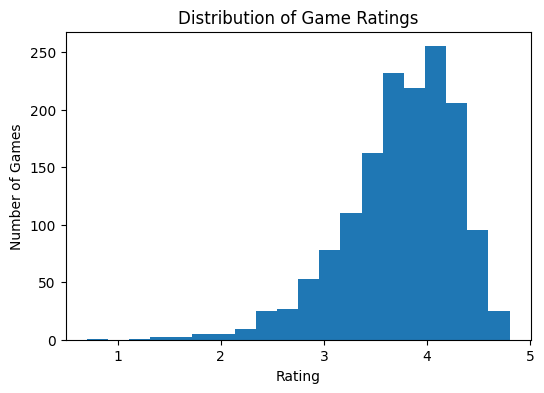

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(games['Rating'], bins=20)
plt.title('Distribution of Game Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Games')
plt.show()

Most games cluster around higher ratings, indicating generally positive user feedback.

EDA 2: Top 10 Most Wishlisted Games

In [ ]:
top_wishlist = games.sort_values('Wishlist', ascending=False).head(10)
top_wishlist[['Title', 'Wishlist']]

,Title,Wishlist
951,Persona 3 Portable,995.0
401,Dark Souls II: Scholar of the First Sin,994.0
867,Dark Souls II: Scholar of the First Sin,994.0
121,Dark Souls II: Scholar of the First Sin,994.0
1087,Persona 2: Eternal Punishment,993.0
938,"Zero Escape: Nine Hours, Nine Persons, Nine Doors",991.0
173,Final Fantasy X,990.0
521,Rain World,987.0
502,Crash Bandicoot N. Sane Trilogy,986.0
235,Crash Bandicoot N. Sane Trilogy,986.0


EDA 3: Engagement vs Rating Relationship

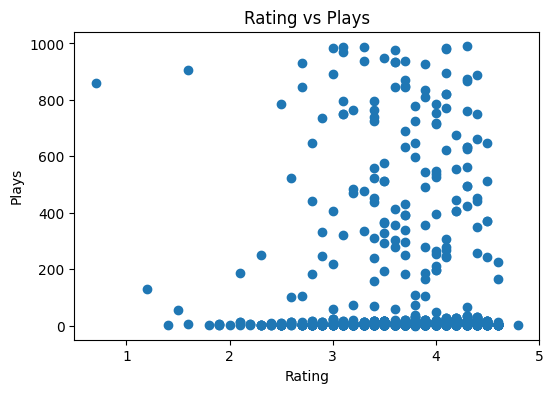

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(games['Rating'], games['Plays'])
plt.xlabel('Rating')
plt.ylabel('Plays')
plt.title('Rating vs Plays')
plt.show()

EDA 4: Most Common Genres

In [ ]:
from collections import Counter

genre_list = games['Genres'].str.strip('[]').str.replace("'", "").str.split(', ')
all_genres = [g for sublist in genre_list for g in sublist]

genre_counts = Counter(all_genres)
genre_counts.most_common(10)

[('Adventure', 1014),
 ('RPG', 523),
 ('Shooter', 353),
 ('Platform', 329),
 ('Indie', 284),
 ('Puzzle', 176),
 ('Brawler', 159),
 ('Strategy', 142),
 ('Simulator', 125),
 ('Turn Based Strategy', 99)]

EDA 5: Release Trend Over Time

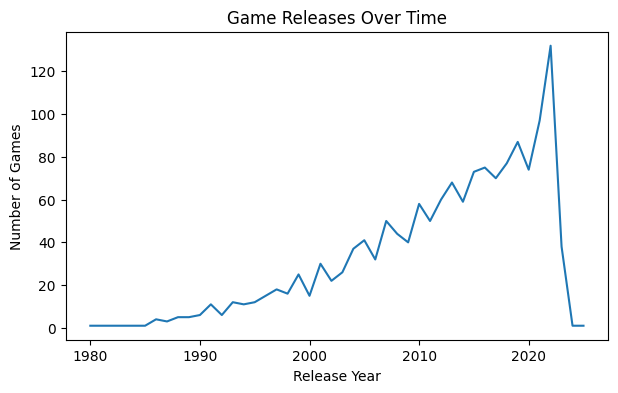

In [ ]:
games['Release Year'] = games['Release Date'].dt.year

games.groupby('Release Year')['Title'].count().plot(figsize=(7,4))
plt.title('Game Releases Over Time')
plt.ylabel('Number of Games')
plt.show()

EDA 6: Global Sales Distribution

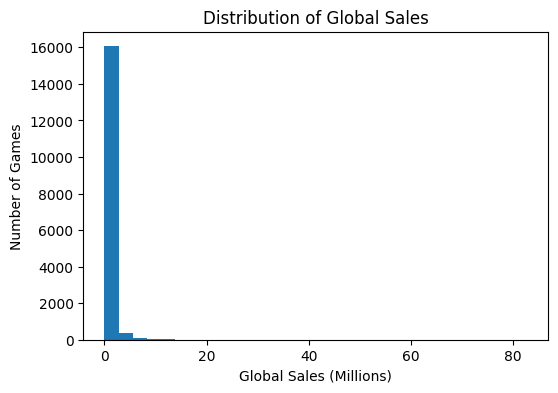

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(vgsales['Global_Sales'], bins=30)
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Number of Games')
plt.show()

EDA 7: Top 10 Best-Selling Games (Global)

In [ ]:
top_games = vgsales.sort_values('Global_Sales', ascending=False).head(10)
top_games[['Name', 'Platform', 'Global_Sales']]

,Name,Platform,Global_Sales
0,Wii Sports,Wii,82.74
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.82
3,Wii Sports Resort,Wii,33.00
4,Pokemon Red/Pokemon Blue,GB,31.37
5,Tetris,GB,30.26
6,New Super Mario Bros.,DS,30.01
7,Wii Play,Wii,29.02
8,New Super Mario Bros. Wii,Wii,28.62
9,Duck Hunt,NES,28.31


EDA 8: Best-Selling Platforms


In [ ]:
platform_sales = (
    vgsales.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

platform_sales

,Global_Sales
Platform,
PS2,1255.64
X360,979.96
PS3,957.84
Wii,926.71
DS,822.49
PS,730.66
GBA,318.50
PSP,296.28
PS4,278.10


EDA 9: Sales by Region

In [ ]:
regional_sales = vgsales[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
regional_sales

,0
NA_Sales,4392.95
EU_Sales,2434.13
JP_Sales,1291.02
Other_Sales,797.75


EDA 10: Sales Trend Over Years

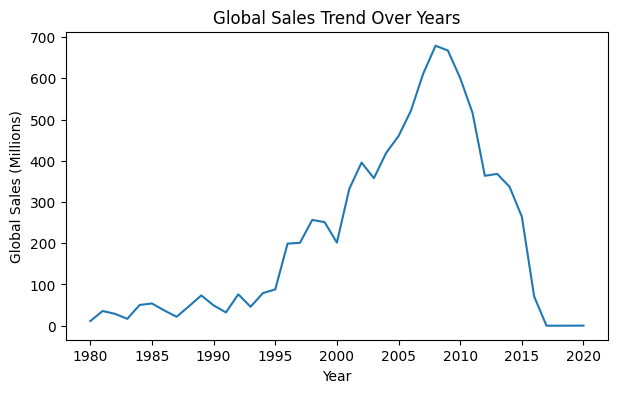

In [ ]:
yearly_sales = (
    vgsales.groupby('Year')['Global_Sales']
    .sum()
)

yearly_sales.plot(figsize=(7,4))
plt.title('Global Sales Trend Over Years')
plt.ylabel('Global Sales (Millions)')
plt.show()

EDA 11: Top Publishers by Sales

In [ ]:
publisher_sales = (
    vgsales.groupby('Publisher')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

publisher_sales

,Global_Sales
Publisher,
Nintendo,1786.56
Electronic Arts,1110.32
Activision,727.46
Sony Computer Entertainment,607.50
Ubisoft,474.72
Take-Two Interactive,399.54
THQ,340.77
Konami Digital Entertainment,283.64
Sega,272.99


Standardize Game Names

In [ ]:
games['Title_clean'] = games['Title'].str.lower().str.strip()
vgsales['Name_clean'] = vgsales['Name'].str.lower().str.strip()

Merging Datasets (Engagement + Sales)

In [ ]:
merged_df = pd.merge(
    games,
    vgsales,
    left_on='Title_clean',
    right_on='Name_clean',
    how='left'
)

In [ ]:
merged_df.shape

(2246, 25)

In [ ]:
merged_df.head()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,...,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Name_clean
0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9,3.9,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17.0,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hades,2019-12-10,['Supergiant Games'],4.3,2.9,2.9,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21.0,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3,4.3,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30.0,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3.5,3.5,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28.0,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hollow Knight,2017-02-24,['Team Cherry'],4.4,3.0,3.0,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21.0,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Check Merge Success Rate

In [ ]:
merged_df['Global_Sales'].notna().value_counts()

,count
Global_Sales,
True,1384
False,862


True → games with sales data

False → engagement-only games

Due to dataset source differences, not all engagement records had corresponding sales entries, which reflects real-world data integration challenges.

In [ ]:
merged_df = merged_df.drop(columns=['Title_clean', 'Name_clean'])

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving video_game_merged_data.csv to video_game_merged_data.csv


Why so many NaNs?

games.csv → modern + engagement-heavy data

vgsales.csv → historical console sales (mostly pre-2016)

Many modern games don’t exist in the sales dataset

This is NOT a mistake — this is real-world data integration.

This actually HELPS because:
we can show how engagement exists even without recorded sales, SQL & Power BI handle NULLs naturally

we can filter dashboards to: “Games with sales data”, “Engagement-only games”

The merged dataset intentionally retains null sales values to reflect data availability differences across sources, enabling realistic analytics rather than forced completeness.

# Advanced EDA on Merged Dataset

In [ ]:
merged_sales = merged_df[merged_df['Global_Sales'].notna()]

EDA 12: Does Rating Affect Global Sales?

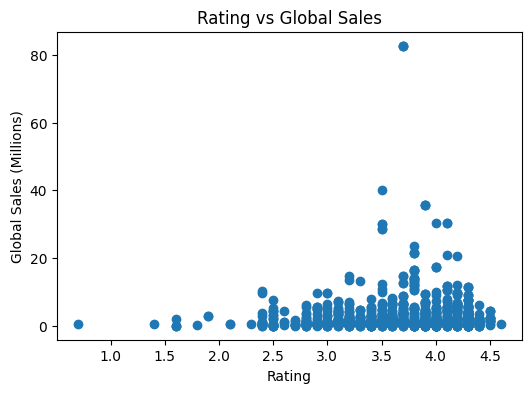

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(merged_sales['Rating'], merged_sales['Global_Sales'])
plt.xlabel('Rating')
plt.ylabel('Global Sales (Millions)')
plt.title('Rating vs Global Sales')
plt.show()

High ratings alone do not guarantee high sales; brand, platform, and timing also play significant roles.

EDA 13: Wishlist vs Global Sales

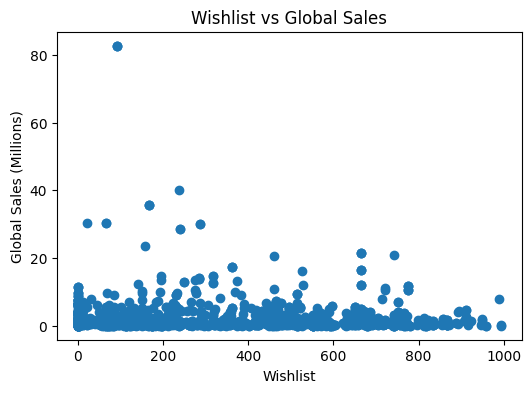

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(merged_sales['Wishlist'], merged_sales['Global_Sales'])
plt.xlabel('Wishlist')
plt.ylabel('Global Sales (Millions)')
plt.title('Wishlist vs Global Sales')
plt.show()

Games with higher wishlist counts tend to show stronger sales performance, indicating effective pre-launch interest.

EDA 14: Genres Generating the Most Global Sales

In [ ]:
merged_sales['Primary_Genre'] = merged_sales['Genres'].str.extract(r"'([^']+)'")

/tmp/ipython-input-3747773121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_sales['Primary_Genre'] = merged_sales['Genres'].str.extract(r"'([^']+)'")


In [ ]:
genre_sales = (
    merged_sales.groupby('Primary_Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

genre_sales

,Global_Sales
Primary_Genre,
Adventure,2026.53
Shooter,386.08
Simulator,270.68
Racing,185.13
Platform,166.67
RPG,151.96
Arcade,97.12
Fighting,86.61
Puzzle,42.88


EDA 15: High Engagement but Low Sales

In [ ]:
engagement_sales = merged_sales[['Title', 'Plays', 'Wishlist', 'Global_Sales']]

engagement_sales.sort_values(
    by=['Wishlist', 'Global_Sales'],
    ascending=[False, True]
).head(10)

,Title,Plays,Wishlist,Global_Sales
1626,Persona 2: Eternal Punishment,1.6,993.0,0.05
1625,Persona 2: Eternal Punishment,1.6,993.0,0.35
268,Final Fantasy X,8.5,990.0,8.05
337,Deus Ex,3.8,958.0,0.01
751,Deus Ex,3.8,958.0,0.01
1274,BioShock Infinite,18.0,949.0,0.67
1273,BioShock Infinite,18.0,949.0,1.76
1272,BioShock Infinite,18.0,949.0,1.96
1597,Drakengard 3,1.9,946.0,0.30
1490,Kid Icarus: Uprising,5.4,924.0,1.28


Some games generate strong engagement but underperform in sales, indicating pricing, platform, or distribution challenges.

EDA 16: Platform Impact on Sales

In [ ]:
platform_sales = (
    merged_sales.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

platform_sales

,Global_Sales
Platform,
Wii,587.00
X360,562.64
PS3,555.88
PS2,232.85
PS4,200.29
DS,172.48
PS,169.76
NES,146.88
GB,129.21


EDA 17: Regional Sales Preference by Genre

In [ ]:
merged_sales[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].describe()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
count,1384.000000,1384.000000,1384.000000,1384.000000
mean,1.260773,0.758288,0.274783,0.246149
std,2.918453,1.799311,0.702145,0.628942
min,0.000000,0.000000,0.000000,0.000000
25%,0.120000,0.070000,0.000000,0.020000
50%,0.450000,0.300000,0.020000,0.080000
75%,1.240000,0.790000,0.190000,0.230000
max,41.490000,29.020000,6.810000,10.570000


In [ ]:
games_sql = games[[
    'Title','Release Date','Rating','Times Listed','Number of Reviews',
    'Plays','Playing','Backlogs','Wishlist','Genres','Team'
]]

In [ ]:
games.columns

Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist', 'Title_clean'],
      dtype='object')

In [ ]:
games_sql.columns = [
    'title','release_date','rating','times_listed','reviews_count',
    'plays','playing','backlogs','wishlist','genres','team'
]

In [ ]:
games_sql.to_csv("games_engagement.csv", index=False)

In [ ]:
from google.colab import files
files.download("games_engagement.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Example if title column is 'Name'
game_sales_sql = vgsales[[
    'Name', 'Platform', 'Year','Genre','Publisher','NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'
]]



In [ ]:
vgsales.columns

Index(['Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Name_clean'],
      dtype='object')

In [ ]:
# Rename columns for SQL
game_sales_sql.columns = [
    'title', 'platform', 'year','genre','publisher','na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales'
]

In [ ]:
# Save to CSV
game_sales_sql.to_csv("game_sales.csv", index=False)

In [ ]:
# Download to your PC
from google.colab import files
files.download("game_sales.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
merged_sql = merged_df[[
    'Title', 'Release Date', 'Rating', 'Times Listed', 'Number of Reviews',
    'Plays', 'Playing', 'Backlogs', 'Wishlist', 'Genres', 'Team',
    'Platform', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'
]]




In [ ]:
# Rename columns to SQL-friendly
merged_sql.columns = [
    'title', 'release_date', 'rating', 'times_listed', 'reviews_count',
    'plays', 'playing', 'backlogs', 'wishlist', 'genres', 'team',
    'platform', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales'
]

In [ ]:
merged_sql.to_csv("merged_game_data.csv", index=False)


In [ ]:
from google.colab import files
files.download("merged_game_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(merged_df.columns)

Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist', 'Release Year', 'Name', 'Platform', 'Year',
       'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales'],
      dtype='object')
